In [1]:
import pandas as pd
import dotenv
from datetime import datetime, timedelta, timezone

dotenv.load_dotenv()

file_path = '../data/reddit_submissions//SuicideWatch_submissions.jsonl'

# Sanity check dataset

In [2]:
with open(file_path, 'r', encoding='utf-8') as f:
    for i in range(5):
        print(f.readline())

{"archived":true,"author":"S2S2S2S2S2","author_flair_background_color":null,"author_flair_css_class":null,"author_flair_richtext":[],"author_flair_text":null,"author_flair_text_color":null,"author_flair_type":"text","brand_safe":false,"can_gild":true,"contest_mode":false,"created_utc":1229436284,"distinguished":null,"domain":"crisiscentre.bc.ca","edited":false,"gilded":0,"hidden":false,"hide_score":false,"id":"7jtxk","is_crosspostable":false,"is_reddit_media_domain":false,"is_self":false,"is_video":false,"link_flair_css_class":null,"link_flair_richtext":[],"link_flair_text":null,"link_flair_text_color":"dark","link_flair_type":"text","locked":false,"media":null,"media_embed":{},"no_follow":false,"num_comments":1,"num_crossposts":0,"over_18":false,"parent_whitelist_status":"no_ads","permalink":"\/r\/SuicideWatch\/comments\/7jtxk\/tips_to_help_us_all_cope_in_during_the_holidays\/","retrieved_on":1522768118,"rte_mode":"markdown","score":15,"secure_media":null,"secure_media_embed":{},"self

# Loading dataset into memory

In [3]:
TIME_FRAME = 365*2

chunksize = 100_000  # tune for your RAM

cutoff_dt = datetime.now(timezone.utc) - timedelta(days=TIME_FRAME)
cutoff_ts = cutoff_dt.timestamp()

frames = []

for chunk in pd.read_json(file_path, lines=True, chunksize=chunksize):
    # keep only last 2 years
    chunk = chunk[chunk["created_utc"] >= cutoff_ts]

    # drop deleted/removed posts
    chunk = chunk[~chunk["selftext"].isin(["[deleted]", "[removed]"])]
    chunk = chunk[~chunk["author"].isin(["[deleted]", "[removed]"])]

    if len(chunk):
        frames.append(chunk)

time_filtered_df = pd.concat(frames, ignore_index=True)
clean_df = time_filtered_df[
    [
        "selftext",
        "created_utc",
        "title",
        "id",
        "subreddit",
        "subreddit_id",
        "retrieved_on",
    ]
].dropna()

# add t3_ prefix to id and rename to post_id
# chromadb uses "id" to identify documents
clean_df["post_id"] = "t3_" + clean_df["id"].astype(str)
clean_df = clean_df.drop(columns=["id"])

print(len(clean_df), f"rows in last {TIME_FRAME} days after filtering")

233051 rows in last 730 days after filtering


# Sanity Check on `selftext` length

In [ ]:
selftext_lengths = clean_df["selftext"].fillna("").apply(lambda x: len(str(x).split()))
title_lengths = clean_df["title"].fillna("").apply(lambda x: len(str(x).split()))

zero_len_df = clean_df[selftext_lengths == 0]

print(f"Number of posts with 0-word selftext: {len(zero_len_df)}")

Number of posts with 0-word selftext: 4829


## Drop rows with less than 50 words

In [12]:

clean_df_with_min_text = clean_df[selftext_lengths > 50]
print(f"{len(clean_df_with_min_text)} rows remain after dropping posts with 50-word selftext")

160808 rows remain after dropping posts with 50-word selftext


## Truncate posts on the last `.?!` punctuation, up to 400 words

In [13]:
import re

MAX_WORDS = 400
SEPARATOR = " | "

def truncate_to_sentence(text: str, max_words: int, min_words: int = 50) -> str:
    words = text.split()
    if len(words) <= max_words:
        return text

    truncated = ' '.join(words[:max_words])
    match = re.search(r'^(.*[.!?])[^.!?]*$', truncated, re.DOTALL)
    if match:
        result = match.group(1).strip()
        if len(result.split()) >= min_words:
            return result

    return truncated.strip()

def truncate_row(row) -> str:
    title = str(row["title"]) if pd.notna(row["title"]) else ""
    selftext = str(row["selftext"]) if pd.notna(row["selftext"]) else ""
    
    title_words = len(title.split())
    selftext_budget = max(0, MAX_WORDS - title_words)
    
    return truncate_to_sentence(selftext, selftext_budget)

original_word_counts = (
    clean_df_with_min_text["title"].fillna("").apply(lambda x: len(x.split())) +
    clean_df_with_min_text["selftext"].fillna("").apply(lambda x: len(x.split()))
)
n_truncated = (original_word_counts > MAX_WORDS).sum()

clean_df_with_min_max_text = clean_df_with_min_text.copy()
clean_df_with_min_max_text["selftext"] = clean_df_with_min_text.apply(truncate_row, axis=1)

print(f"Capped at {MAX_WORDS} words, truncated at sentence boundary.")
print(f"Rows affected: {n_truncated}")

if n_truncated > 0:
    example_idx = original_word_counts[original_word_counts > MAX_WORDS].index[0]
    row = clean_df_with_min_max_text.loc[example_idx]
    doc = row["title"] + SEPARATOR + row["selftext"]
    total_words = len(doc.split())
    print(f"\nExample (post_id={row['post_id']}, original words={int(original_word_counts.loc[example_idx])}):")
    print(f"  Words now: {total_words}")
    print(f"  Title: {row['title'][:80]}")
    print(f"  Selftext ending: ...{row['selftext'][-300:]}")

Capped at 400 words, truncated at sentence boundary.
Rows affected: 17997

Example (post_id=t3_1cyqud5, original words=419):
  Words now: 398
  Title: I don't think I'm meant to live at all
  Selftext ending: ...t think I'm ever capable of living a normal life after this. I feel like I'll be in a constant blame cycle wherever i go. I've been fantasising about the idea of ending it with the poison capsule. I want to go to a place full of trees and bushes and just lay there, drink my poison and go peacefully.


### Note to self

- Possible iterations
    - Check language of all text (english only)
    - Remove special characters (emojis, non-english)

# Data sanity check

In [14]:
print(clean_df_with_min_max_text.head())

                                            selftext  created_utc  \
0  I can't Handel my life any more and there is c...   1716463721   
1  I'm in a bad way. My life has burned down and ...   1716463822   
3  I’m still in high school and I thought everyth...   1716463846   
4  Male 22 y/o   \nThe tunnel, as I go on, which ...   1716463891   
7  I have nothing to live for, I have no future t...   1716464131   

                                     title     subreddit subreddit_id  \
0             How to suicide in your sleep  SuicideWatch     t5_2qpzs   
1                                 Overdose  SuicideWatch     t5_2qpzs   
3                     My mom kicked me out  SuicideWatch     t5_2qpzs   
4  The tunnel seems to be getting narrower  SuicideWatch     t5_2qpzs   
7                       I wanna die so bad  SuicideWatch     t5_2qpzs   

   retrieved_on     post_id  
0    1716463737  t3_1cyqi2u  
1    1716463839  t3_1cyqj3f  
3    1716463861  t3_1cyqjbm  
4    1716463910  t3_1cyqjr

Total posts: 160,808
count    160808.000000
mean        179.091575
std         106.664475
min          51.000000
25%          90.000000
50%         146.000000
75%         250.000000
max         399.000000
Name: selftext, dtype: float64


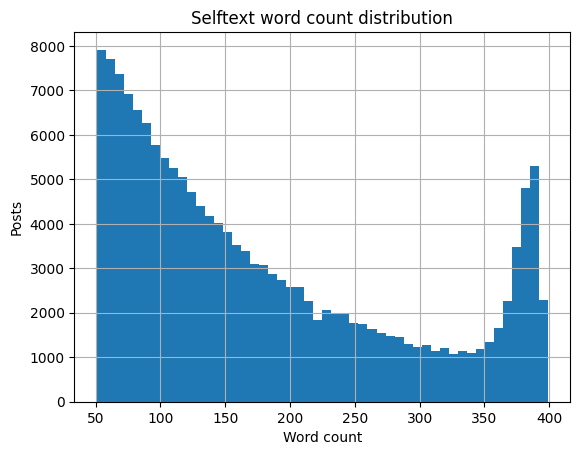

In [15]:
print(f"Total posts: {len(clean_df_with_min_max_text):,}")

import matplotlib.pyplot as plt

word_counts = clean_df_with_min_max_text["selftext"].apply(lambda x: len(x.split()))
print(word_counts.describe())
word_counts.hist(bins=50)
plt.xlabel("Word count")
plt.ylabel("Posts")
plt.title("Selftext word count distribution")
plt.show()

# Sample down to 50k posts and export csv

In [18]:
sample_df = clean_df_with_min_max_text.sample(n=50000, random_state=67)
word_counts = sample_df["selftext"].apply(lambda x: len(x.split()))
print(word_counts.describe())

count    50000.000000
mean       179.216760
std        106.609988
min         51.000000
25%         90.000000
50%        146.000000
75%        251.000000
max        399.000000
Name: selftext, dtype: float64


In [19]:
sample_df.to_csv('../data/suicide_watch_sample_50k_v1.csv')